# Linear interpolation with more forecasters version
Also included Covidhub-train-ensemble.


Compared to 0312 version, eta_f is no longer \sqrt{log F / T} x 2 by default. It's \sqrt{log F / T} by default

In [19]:
import numpy as np
import pandas as pd
import pickle

d = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp.pkl', 'rb'))
forecasts_dict = d['forecasts_dict']
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
dates_list = d['dates_list']
Y = d['Y']

print(f_list)
print(alpha_list)
print(dates_list)

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']
[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
Index(['2021-02-23', '2021-02-24', '2021-02-25', '2021-02-26', '2021-02-27',
       '2021-02-28', '2021-03-01', '2021-03-02', '2021-03-03', '2021-03-04',
       ...
       '2023-06-01', '2023-06-02', '2023-06-03', '2023-06-04', '2023-06-05',
       '2023-06-06', '2023-06-07', '2023-06-08', '2023-06-09', '2023-06-10'],
      dtype='str', length=838)


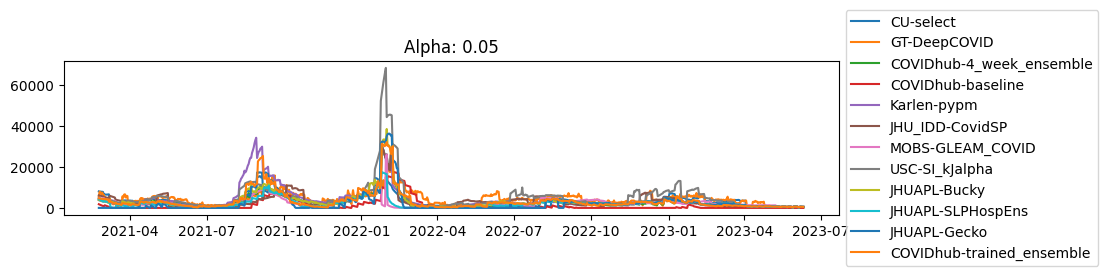

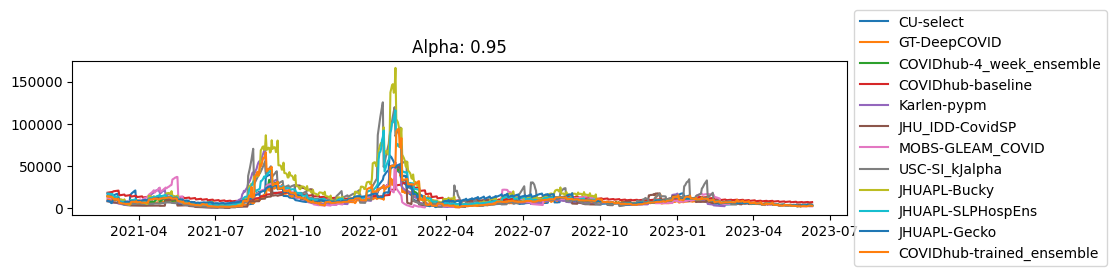

In [20]:
import matplotlib.pyplot as plt

for alpha in [0.05, 0.95]:
    plt.figure(figsize=(10, 2))
    for forecaster in f_list:
        plt.plot(pd.to_datetime(d['dates_list']), 
        forecasts_dict[4][f'{forecaster}'][alpha], label=forecaster) #
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f'Alpha: {alpha}')
    plt.show()


In [21]:
pd.Series(Y).max() # -> unit as 100

np.float64(23473.0)

In [22]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Callable, Tuple
import importlib
import metrics
import multi_q_minmax_solver
importlib.reload(metrics)
importlib.reload(multi_q_minmax_solver)
from metrics import elementary_scores_grid_N, elementary_scores_grid_N_m, elementary_scores_grid_N_F, pinball_loss, create_scoring_function_class
from multi_q_minmax_solver import multi_q_minmax_solver, minimax_value_neg


def omni_error_from_scores(scores: np.ndarray):
    # scores: (T, N, m, ..)
    # return: (T, ..)
    if scores.ndim == 3:
        return np.max(scores.cumsum(axis=0), axis=(1,2)) / (np.arange(scores.shape[0]) + 1)
    elif scores.ndim == 4:
        return np.max(scores.cumsum(axis=0), axis=(1,2)) / (np.arange(scores.shape[0])[:, None] + 1)
    else:
        raise ValueError(f"scores.ndim: {scores.ndim}")



# ============================================================================
# Main Omniprediction Experiment
# ============================================================================

# maybe to add unit size and flexible Y range here. Something like if Y value that is higher than current range of Y, add more \theta_is and put some weights there. (Should prove if we still have same Hedge performance bound)
def omniprediction_multiq_online(Y: pd.Series, forecasts_dict: dict, Y_max_padding:float = None, unit: int = 100, m: int = 10, 
                                alpha_list: List[float] = [0.5], eta_multiplier: float = 1,
                                eta_f_multiplier: float = 1, seed: int = 42, verbose: bool = False):
    """
    Run omniprediction experiment and compare against base forecasters.
    
    Parameters
    ----------
    T : int
        Time horizon / number of samples
    m : int
        Number of discretized theta values
    F : int
        Number of base forecasters
    alpha_list : List[float]
        List of quantile levels
    eta : float
        Learning rate for weights w_i
    eta_f : float
        Learning rate for forecaster selection v_{i,j}
    seed : int
        Random seed
    
    Returns
    -------
    results : dict
        Dictionary containing all results
    """
    if verbose:
        print("="*70)
        print("OMNIPREDICTION MULTI-QUANTILE EXPERIMENT")
        print("="*70)
    
    np.random.seed(seed)

    
    ###########################
    # NO-X ONLINE PART
    ###########################
    # Import Y and base forecasters
    dates_list = sorted(Y.index)
    T = len(dates_list)


    # Get the min and max of forecasters predictions
    forecast_min = np.inf
    forecast_max = -np.inf
    for f_name, forecast_dic in forecasts_dict.items():
        forecast_min = min(forecast_min, forecast_dic[min(alpha_list)].min())
        forecast_max = max(forecast_max, forecast_dic[max(alpha_list)].max())

    Y_rounded_min = min(int(np.floor(forecast_min / unit)), 0)
    Y_rounded_max = int(np.ceil(forecast_max / unit))
    m = Y_rounded_max - Y_rounded_min
    thetas = np.arange(Y_rounded_min, Y_rounded_max) + 0.5

    F = len(forecasts_dict.keys())
    forecaster_names = list(forecasts_dict.keys())

    alpha_list = np.array(alpha_list)
    assert len(alpha_list.shape) == 1
    N = alpha_list.shape[0]
    
    eta = eta_multiplier * np.sqrt(np.log(m)/T)
    eta_f = eta_f_multiplier * np.sqrt(np.log(F)/T) 

    for forecaster in forecaster_names:
        for alpha in alpha_list:
            if alpha not in forecasts_dict[forecaster].keys():
                raise ValueError(f"alpha {alpha} not in forecasts_dict[{forecaster}].keys()")
            assert set(forecasts_dict[forecaster][alpha].index) == set(Y.index), f'forecasts_dict[forecaster][alpha].index: {forecasts_dict[forecaster][alpha].index}, Y.index: {Y.index}'

    Y = (Y/unit).round(decimals=0).copy()
    
    forecasts_dict_rounded = {}
    for forecaster in forecaster_names:
        forecasts_dict_rounded[forecaster] = {}
        for alpha in alpha_list:
            forecasts_dict_rounded[forecaster][alpha] = (forecasts_dict[forecaster][alpha] / unit).round(decimals=0)
            
    all_forecaster_preds_all_dates = np.array([
        [
            [
                forecasts_dict_rounded[forecaster][alpha][date] 
                for forecaster in forecaster_names
            ] 
            for alpha in alpha_list
        ]
        for date in dates_list
    ])   # shape (T, N, F)

    if verbose:
        print(f"\nData:")
        print(f"  Number of dates: {T}")
        print(f"  Y range: [{min(Y.values):.3f}, {max(Y.values):.3f}]")
        print(f"  Unit size: {unit}")
        print(f"  Number of discretized thetas: {m}")
        print(f"  Number of base forecasters: {F}")
        print(f"  Forecaster names: {forecaster_names}")
        print(f"  Quantile level: alpha = {alpha_list} ({len(alpha_list)} levels)")
    
    ###########################


    # Initialize algorithm state
    w = np.ones((N, m)) / (N*m)  # Uniform weights over thetas
    v = np.ones((N, m, F)) / F  # Uniform weights over forecasters for each theta
    f_selected_indices = np.zeros((N, m), dtype=np.int32)  # Initially all use first forecaster
    
    pinball_v = np.ones((N,F)) / F  # each quantilie level separately
    pinball_f_selected_indices = np.zeros(N, dtype=np.int32)
    ql_v = np.ones(F) / F  # all quantile levels together
    ql_f_selected_index = 0
    
    # Storage for regrets over time
    y_arr = np.array(Y.values)
    phat_history = np.zeros((T, N))
    w_history = np.zeros((T, N, m))
    v_history = np.zeros((T, N, m, F))
    minimax_value_history = np.zeros((T,))
    omni_error_history = np.zeros((T, N, m))
    preds_history = np.zeros((T, N, F))     # Predictions of each forecaster
    forecasters_score_history = np.zeros((T, N, m, F))
    forecasters_selection_history = np.zeros((T, N, m))

    pinball_selection_history = np.zeros((T, N))
    pinball_preds_history = np.zeros((T, N))
    ql_selection_history = np.zeros((T))
    ql_preds_history = np.zeros((T, N))
    
    if verbose:
        print(f"\nRunning omniprediction algorithm...")
    
    for t, date in tqdm(enumerate(dates_list)):
        # x_t = X[t]
        y_t = Y[date]
        
        # Step 1: Compute P_t
        all_forecaster_preds = all_forecaster_preds_all_dates[t,:,:]
        
        # Select one forecaster per theta level (currently using index)
        # Use advanced NumPy indexing for compactness and speed
        row_idx = np.arange(N)[:, None]
        col_idx = f_selected_indices
        forecaster_preds = all_forecaster_preds[row_idx, col_idx]
        assert forecaster_preds.shape == (N, m)


        phat_dict_list, Vn_values = multi_q_minmax_solver(
            theta_weights=w,
            thetas=thetas,
            forecast_values=forecaster_preds,
            tol=1e-12
        )
        minimax_value_history[t] = minimax_value_neg(alpha_list=alpha_list, Vn_values=Vn_values)

        phat = np.array([phat_dict["phat"] for phat_dict in phat_dict_list])
        phat_history[t,:] = phat
        k_star = np.array([phat_dict["k_star"] for phat_dict in phat_dict_list])
        k_star_prob = np.array([phat_dict["k_star_prob"] for phat_dict in phat_dict_list])
        
        # Step 2: Compute expected score under P_t (vectorized)
        phat_score = k_star_prob[:, None] * elementary_scores_grid_N((k_star / m), y_t, thetas, alpha_list) + \
            (1 - k_star_prob[:, None]) * elementary_scores_grid_N((k_star + 1) / m, y_t, thetas, alpha_list)

        f_selected_score = elementary_scores_grid_N_m(forecaster_preds, y_t, thetas, alpha_list)
        
        assert phat_score.shape == (N, m), f'phat_score.shape: {phat_score.shape}, N: {N}, m: {m}'
        assert f_selected_score.shape == (N, m), f'f_selected_score.shape: {f_selected_score.shape}, N: {N}, m: {m}'
        
        # Step 3: Update weights w_i
        w_history[t,:] = w
        v_history[t,:,:] = v
        log_w = np.log(w + 1e-10)
        log_w += eta * (phat_score - f_selected_score)
        
        # Normalize in log space
        max_log_w = np.max(log_w)
        log_w -= max_log_w
        w = np.exp(log_w)
        w /= np.sum(w)
        
        # Step 4: Update forecaster selection v_{i,j} (vectorized implementation)
        preds = all_forecaster_preds    # (N, F)
        preds_history[t,:, :] = preds
        scores = elementary_scores_grid_N_F(preds, float(y_t), thetas, alpha_list)
        
        log_v = np.log(v + 1e-10)
        log_v -= eta_f * scores
        
        # Normalize in log-space for numerical stability
        max_log_v = np.max(log_v, axis=2, keepdims=True)
        log_v -= max_log_v
        
        v = np.exp(log_v)
        v /= np.sum(v, axis=2, keepdims=True)
        
        # Step 4-2: Hedge algorithm using pinball loss
        # Store selection history in vectorized manner
        pinball_selection_history[t, :] = pinball_f_selected_indices
        pinball_preds_history[t, :] = preds[np.arange(N), pinball_f_selected_indices]
        
        # Vectorized pinball loss computation and update
        # Compute pinball losses for all (N, F) at once
        pinball_losses = pinball_loss(preds, y_t, alpha_list[:, None])  # expects broadcasting: preds (N, F), alpha_list (N,1) -> (N,F)
        assert pinball_losses.shape == (N, F)

        # Vectorized update of pinball_v (N,F)
        pinball_v = np.log(pinball_v + 1e-10)
        pinball_v -= eta_f * pinball_losses / m
        pinball_v -= np.max(pinball_v, axis=1, keepdims=True)
        pinball_v = np.exp(pinball_v)
        pinball_v /= np.sum(pinball_v, axis=1, keepdims=True)

        # Vectorized forecaster selection for all n at once
        # Use cumulative sums for np.random.choice efficiency
        cum_v = np.cumsum(pinball_v, axis=1)
        r = np.random.rand(N, 1)
        pinball_f_selected_indices = (cum_v > r).argmax(axis=1)


        # Step 4-3: Hedge algorithm using QL loss
        ql_selection_history[t] = ql_f_selected_index
        ql_preds_history[t,:] = preds[:, ql_f_selected_index]
        ql_loss = np.mean(pinball_losses, axis=0)
        ql_v = np.log(ql_v + 1e-10)
        ql_v -= eta_f * ql_loss / m
        ql_v -= np.max(ql_v)
        ql_v = np.exp(ql_v)
        ql_v /= np.sum(ql_v)
        ql_f_selected_index = np.random.choice(F, p=ql_v)


        # Step 5: Sample new forecasters
        # for n in range(N):
        #     for i in range(m):
        #         j_ni = np.random.choice(F, p=v[n,i,:])
        #         f_selected_indices[n,i] = j_ni
        cum_v = np.cumsum(v, axis=2)          # shape (N, m, F)
        r = np.random.rand(N, m, 1)           # shape (N, m, 1)
        f_selected_indices = (cum_v > r).argmax(axis=2)  # shape (N, m)
    
        # Compute regret at time t
        forecasters_selection_history[t,:,:] = f_selected_indices
        forecasters_score_history[t,:,:,:] = scores
        # omni_error_history[t,:,:] = np.stack([[S(phat[n], y_t) for S in scoring_functions[n]] for n in range(N)])
        omni_error_history[t,:,:] = elementary_scores_grid_N(phat, y_t, thetas, alpha_list)


    # print(f"\n" + "="*70)
    # print("RESULTS")
    # print("="*70)

    # print(f"\nOmniprediction error (from learned P):")
    # print(f"  sup_{{S in S_alpha}} E[S(P(X), Y)] = {omni_error:.6f}")
    
    # # Compute regret of each base forecaster
    # print(f"\nRegret of each base forecaster:")
    # print(f"  sup_{{S in S_alpha}} E[S(f_j(X), Y)]")

    omni_score_trace = omni_error_from_scores(omni_error_history)
    assert omni_score_trace.shape == (T,)

    forecasters_score_trace = omni_error_from_scores(forecasters_score_history)
    assert forecasters_score_trace.shape == (T, F)

    best_forecaster_score_trace = forecasters_score_trace.min(axis=1)
    
    # Theoretical bound
    # theoretical_bound = np.sqrt(np.log(m * F) / T)
    # print(f"\nTheoretical omniprediction guarantee:")
    # print(f"  O(sqrt(log(m*F)/T)) = O(sqrt({np.log(m*F):.2f}/{T}))")
    # print(f"                      = O({theoretical_bound:.6f})")
    
    # Return results
    return {
        'phat_history': phat_history,
        # 'w_history': w_history,
        # 'v_history': v_history,
        'minimax_value_history': minimax_value_history, # (T,)
        # 'omni_error_history': omni_error_history,   # (T, N, m) 
        'forecasters_preds_history': preds_history, # (T, N, F)
        # 'forecasters_score_history': forecasters_score_history, # (T, N, m, F)
        # 'forecasters_selection_history': forecasters_selection_history, # (T, N, m)
        'omni_score_trace': omni_score_trace,   # (T,)
        'forecasters_score_trace': forecasters_score_trace, # (T, F)    
        'best_forecaster_score_trace': best_forecaster_score_trace, # (T,)
        'thetas': thetas,
    
        'pinball_selection_history': pinball_selection_history,     # (T, N)
        'pinball_preds_history': pinball_preds_history,             # (T, N)
        'ql_selection_history': ql_selection_history,               # (T,)
        'ql_preds_history': ql_preds_history,                       # (T, N)
        
        'Y': Y,
        'y_arr': y_arr,
        'dates_list': dates_list,
        'T': T,
        'unit': unit,
        'm': m,
        'F': F,
        'alpha_list': alpha_list,
        'forecaster_names': forecaster_names,
        # 'theoretical_bound': theoretical_bound,
    }


In [ ]:
class OmniResult():
    def __init__(self, results: dict):
        import importlib
        importlib.reload(metrics)
        from metrics import elementary_scores_grid_T_N
        self.results = results
        self.alpha_list = results['alpha_list']
        self.Y_arr = results['y_arr']
        self.m = results['m']
        self.F = results['F']
        self.T = results['T']
        self.N = self.alpha_list.shape[0]
        
        self.alpha_list = results['alpha_list']
        self.unit = results['unit']
        self.thetas = results['thetas']

        ens_preds = results['forecasters_preds_history'][:,:,-1] 
        assert results['forecaster_names'][-1] == 'COVIDhub-trained_ensemble'

        pinball_scores = elementary_scores_grid_T_N(self.results['pinball_preds_history'], self.Y_arr, self.thetas, self.alpha_list)
        ql_scores = elementary_scores_grid_T_N(self.results['ql_preds_history'], self.Y_arr, self.thetas, self.alpha_list)
        ensemble_scores = elementary_scores_grid_T_N(ens_preds, self.Y_arr, self.thetas, self.alpha_list)
        
        self.pinball_omni_score_trace = np.max(np.cumsum(pinball_scores, axis=0), axis=(1,2)) / np.arange(1, self.T+1)
        self.ql_omni_score_trace = np.max(np.cumsum(ql_scores, axis=0), axis=(1,2)) / np.arange(1, self.T+1)
        self.ensemble_omni_score_trace = np.max(np.cumsum(ensemble_scores, axis=0), axis=(1,2)) / np.arange(1, self.T+1)

        # Best Val and Best Test
        forecasters_preds_history = results['forecasters_preds_history']    # (T, N, F)
        forecasters_score_trace = results['forecasters_score_trace']   # (T, F)
        best_val_forecaster = np.concatenate([[0], np.argmin(forecasters_score_trace, axis=1)[:-1]])   # [0] as padding to look one step before
        best_test_forecaster = np.argmin(forecasters_score_trace, axis=1)

        self.best_val_forecaster_preds = forecasters_preds_history[np.arange(self.T), :, best_val_forecaster]
        self.best_test_forecaster_preds = forecasters_preds_history[np.arange(self.T), :, best_test_forecaster]   # (T, N)
        # best_val_forecaster_error = forecasters_score_trace[np.arange(T), best_val_forecaster]
        # best_test_forecaster_error = forecasters_score_trace[np.arange(T), best_test_forecaster]     # (T, )
        

    def simple_plot(self, ax=None):
        """Plot omniprediction experiment results."""
        assert self.results['forecaster_names'][-1] == 'COVIDhub-trained_ensemble'
        dates_list = pd.to_datetime(self.results['dates_list'])

        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4))

        ax.plot(dates_list, (self.results['omni_score_trace'] - self.results['best_forecaster_score_trace']), label='Omniprediction error')
        # ax.plot(dates_list, results['best_forecaster_score_trace'], label='Best forecaster')
        ax.plot(dates_list, (self.pinball_omni_score_trace - self.results['best_forecaster_score_trace']), label='Pinball')
        ax.plot(dates_list, (self.ql_omni_score_trace - self.results['best_forecaster_score_trace']), label='QL')
        ax.plot(dates_list, (self.ensemble_omni_score_trace - self.results['best_forecaster_score_trace']), label='COVIDhub-trained_ens')
        #ax.plot(dates_list, [np.minimum(np.sqrt(np.log(self.m * self.F) / (t+1)), 1.0) for t in np.arange(self.T)], '--', label='Theoretical bound')
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.set_xlabel('Time t')
        ax.tick_params(axis='x', labelrotation=45)
        # ax.legend()

        return ax

    def minimax_plot(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        
        dates_list = pd.to_datetime(self.results['dates_list'])
        ax.plot(dates_list, self.results['minimax_value_history'], label='Minimax value')
        ax.set_xlabel('Time t')
        ax.tick_params(axis='x', labelrotation=45)
        ax.legend()

        return ax


    def single_q_pred_df (self, ia):
        return pd.DataFrame(
                np.concatenate(
                    [
                        self.results['phat_history'][:, ia][:, None],
                        self.results['forecasters_preds_history'][:, ia, :],
                        self.best_val_forecaster_preds[:, ia][:, None], 
                        self.best_test_forecaster_preds[:, ia][:, None],
                        self.results['pinball_preds_history'][:, ia][:, None], 
                        self.results['ql_preds_history'][:, ia][:, None], 
                        self.Y_arr[:, None]
                    ], axis=1
                ),
                columns = (['phat'] +
                            [f'pred_{i}' for i in range(1, self.results['forecasters_preds_history'].shape[2] + 1)] +
                            ['best_val_pred', 'best_test_pred', 'pinball_pred', 'ql_pred', 'Y']
                            )
            )


    def plot_prediction_panel(self, alpha, relative, ax=None):
        dates_list = pd.to_datetime(self.results['dates_list'])
        Y_arr = self.Y_arr
        unit = self.unit
        forecasters_preds_history = self.results['forecasters_preds_history']
        forecaster_names = self.results['forecaster_names']

        if isinstance(alpha, int):
            df = self.single_q_pred_df(alpha)
        else:
            ia = np.where(self.alpha_list == alpha)[0][0]
            df = self.single_q_pred_df(ia)

        if ax is None:
            fig, ax = plt.subplots(figsize=(18, 10))
        if not relative:
            assert forecaster_names[-1] == 'COVIDhub-trained_ensemble'

            for f in range(self.F):
                if f < self.F-1:
                    ax.plot(dates_list, unit*forecasters_preds_history[:, ia, f], color='gray', linewidth=1, linestyle='--', label=f'Base{forecaster_names[f]}')
                else:
                    ax.plot(dates_list, unit*forecasters_preds_history[:, ia, f], color='red', linewidth=1, label='COVIDhub-ens')

            ax.plot(dates_list, unit*Y_arr, color='black', linewidth=2, label='True Y')
            # ax.plot(dates_list, unit*df[f'best_test_pred'], color='red', linewidth=1, label='Best Base Forecaster (hindsight)')
            ax.plot(dates_list, unit*df['phat'], color='blue', linewidth=2, label='MultiQ Omniprediction')
            ax.plot(dates_list, unit*df[f'ql_pred'], color='green', linewidth=1, linestyle='--', label='(Unweighted) Quantile loss optimization')
            ax.set_ylabel('Predicted Y')
        else:
            ax.plot(dates_list, unit*(df[f'ql_pred'] - Y_arr), color='red', linewidth=2, label='MultiQ QL')
            ax.plot(dates_list, unit*(df[f'best_val_pred'] - Y_arr), color='green', linewidth=1, label='Best VAL')
            ax.plot(dates_list, unit*(df['phat'] - Y_arr), color='blue', linewidth=2, label='MultiQ Omniprediction')
            ax.hlines(0, dates_list[0], dates_list[-1], color='black', linewidth=0.5, linestyle='--')
            ax.set_ylabel('Predicted Y - True Y')
        ax.set_xlabel('Dates')
        ax.set_title(f'alpha = {alpha}')
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


    def plot_prediction_panel_all(self, relative=False):
    
        fig, ax = plt.subplots(self.N, 1, figsize=(15, 15))
        for ia, alpha in enumerate(self.alpha_list):
            self.plot_prediction_panel(
                alpha=alpha, relative=relative, ax=ax[ia]
            )
        fig.tight_layout()
        plt.show()
        

In [24]:
for w in range(1,5):
    forecast_min = np.inf
    forecast_max = -np.inf
    for f_name, forecast_dic in forecasts_dict[w].items():
        forecast_min = min(forecast_min, forecast_dic[0.05].min())
        forecast_max = max(forecast_max, forecast_dic[0.95].max())

    print(f'{w}wk ahead: {forecast_min}, {forecast_max}')

1wk ahead: 0.0, 65996.7446656277
2wk ahead: 0.0, 96855.4700709372
3wk ahead: 0.0, 132586.513024737
4wk ahead: 0.0, 166297.207969915


## Experiment settings (common)

In [73]:
def decimal_to_str(eta):
    return int(eta) if eta >= 1 else str(eta).replace('.', '')

def exp_name_string(w, eta, etaf, seed):
    return f"wk{w}_eta{decimal_to_str(eta)}_etaf{decimal_to_str(etaf)}_seed{seed}"

save_folder = 'hospitalizations0315'
SAVE_DIR = f'../results/{save_folder}'

alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])

### Fix eta_w

In [ ]:
eta_multiplier = 1

for w in range(1,5):
    for eta_f_multiplier in [1, 2, 4, 8, 16]:
        print(f"Running wk{w} with eta_f_multiplier={eta_f_multiplier}...")
        for seed in range(1,11):
            results = omniprediction_multiq_online(Y=d['Y'][d['dates_list']], 
                                                    forecasts_dict=forecasts_dict[w], 
                                                    unit=100, 
                                                    alpha_list=alpha_list_here, 
                                                    eta_multiplier=eta_multiplier, 
                                                    eta_f_multiplier=eta_f_multiplier, 
                                                    seed=seed, 
                                                    verbose=False
                                                    )
            exp_name = exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)
            omni_result = OmniResult(results)
            pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
            pickle.dump(omni_result, open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'wb'))

### Fix eta_f

In [76]:
alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])

eta_f_multiplier = 8
for eta_multiplier in [0.5, 2, 4]:
    for w in range(1,5):
        print(f"Running wk{w} with eta_multiplier={eta_multiplier}...")
        for seed in range(1,11):
            results = omniprediction_multiq_online(Y=d['Y'][d['dates_list']], 
                                                    forecasts_dict=forecasts_dict[w], 
                                                    unit=100, 
                                                    alpha_list=alpha_list_here, 
                                                    eta_multiplier=eta_multiplier, 
                                                    eta_f_multiplier=eta_f_multiplier, 
                                                    seed=seed, 
                                                    verbose=False)
            omni_result = OmniResult(results)
            exp_name = exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)
            pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
            pickle.dump(omni_result, open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'wb'))

Running wk1 with eta_multiplier=0.5...


838it [00:01, 469.29it/s]
838it [00:01, 485.02it/s]
838it [00:01, 476.31it/s]
838it [00:01, 484.85it/s]
838it [00:01, 483.67it/s]
838it [00:01, 474.85it/s]
838it [00:01, 479.21it/s]
838it [00:01, 422.13it/s]
838it [00:01, 436.50it/s]
838it [00:01, 467.98it/s]


Running wk2 with eta_multiplier=0.5...


838it [00:02, 287.95it/s]
838it [00:02, 339.32it/s]
838it [00:02, 324.65it/s]
838it [00:02, 347.16it/s]
838it [00:02, 348.21it/s]
838it [00:02, 350.48it/s]
838it [00:02, 333.67it/s]
838it [00:02, 336.59it/s]
838it [00:02, 335.87it/s]
838it [00:02, 327.81it/s]


Running wk3 with eta_multiplier=0.5...


...

838it [00:02, 331.25it/s]
838it [00:02, 341.91it/s]
838it [00:02, 334.38it/s]
838it [00:02, 305.64it/s]
838it [00:02, 331.30it/s]
838it [00:02, 345.21it/s]
838it [00:02, 345.09it/s]
838it [00:02, 342.48it/s]
838it [00:02, 336.37it/s]
838it [00:02, 345.22it/s]


Running wk3 with eta_multiplier=4...


838it [00:03, 252.99it/s]
838it [00:03, 244.41it/s]
838it [00:03, 258.07it/s]
838it [00:03, 255.78it/s]
838it [00:03, 250.78it/s]
838it [00:03, 249.21it/s]
838it [00:03, 262.34it/s]
838it [00:03, 244.71it/s]
838it [00:03, 259.98it/s]
838it [00:03, 254.06it/s]


Running wk4 with eta_multiplier=4...


838it [00:04, 192.19it/s]
838it [00:04, 196.84it/s]
838it [00:04, 202.30it/s]
838it [00:03, 210.23it/s]
838it [00:04, 207.73it/s]
838it [00:04, 195.29it/s]
838it [00:04, 194.91it/s]
838it [00:04, 198.57it/s]
838it [00:04, 197.81it/s]
838it [00:04, 192.75it/s]


## Plots

### Omniprediction error

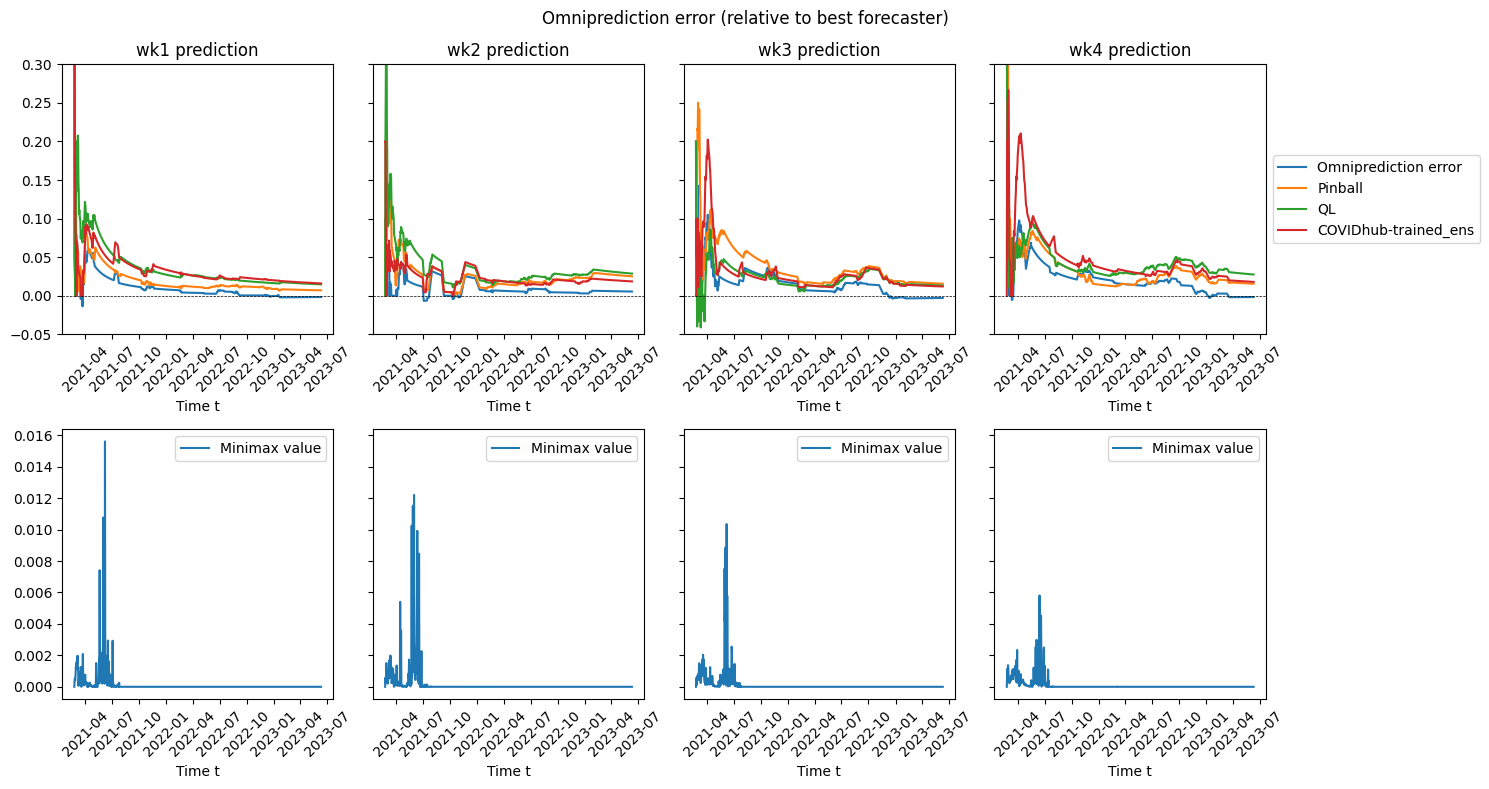

In [108]:
fig, ax = plt.subplots(2, 4, figsize=(15, 8), sharey='row')

for w in range(1,5):
    results = pickle.load(open(f"{SAVE_DIR}/results_wk{w}_eta1_etaf8_seed1.pkl", 'rb'))
    omni_result = OmniResult(results)
    ax[0, w-1] = omni_result.simple_plot(ax=ax[0,w-1])
    ax[0, w-1].set_title(f'wk{w} prediction')
    ax[0, w-1].set_ylim(-0.05, 0.3)
    ax[1,w-1] = omni_result.minimax_plot(ax=ax[1,w-1])
    if w == 4:
        ax[0, w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle('Omniprediction error (relative to best forecaster)')
fig.tight_layout()
plt.show()

0.10978520286396182
0.1288782816229117
0.1366348448687351
0.0030916680180884826
0.005342144125189977
0.00510723352712483


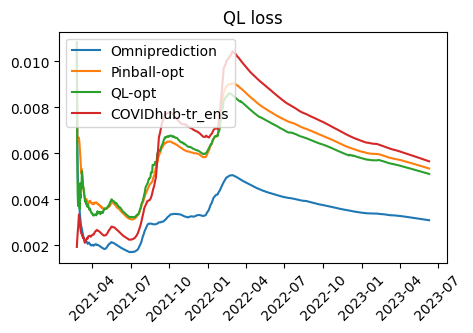

In [79]:
from metrics import ql_loss
w=4
eta_f_multiplier = 16

exp_name = exp_name_string(w, 1, eta_f_multiplier, seed=1)

omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'rb'))
results = omni_result.results

T = results['T']
Y = results['Y']
m = results['m']

print(results['omni_score_trace'][T-1])
print(omni_result.pinball_omni_score_trace[T-1])
print(omni_result.ql_omni_score_trace[T-1])

print(ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m)
print(ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m)
print(ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['phat_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='Omniprediction')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='Pinball-opt')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['ql_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='QL-opt')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['forecasters_preds_history'][:,:,-1], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='COVIDhub-tr_ens')
plt.xticks(rotation=45)
plt.legend()
plt.title('QL loss')
plt.show()

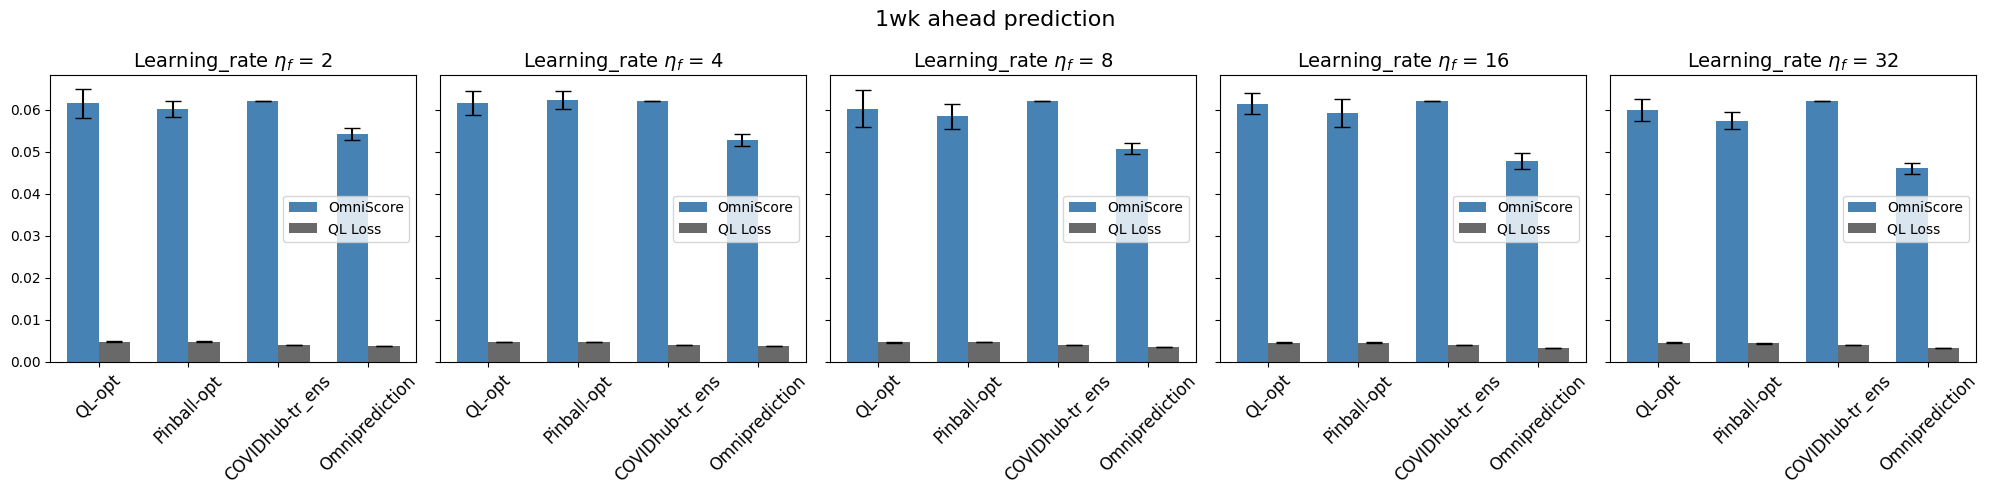

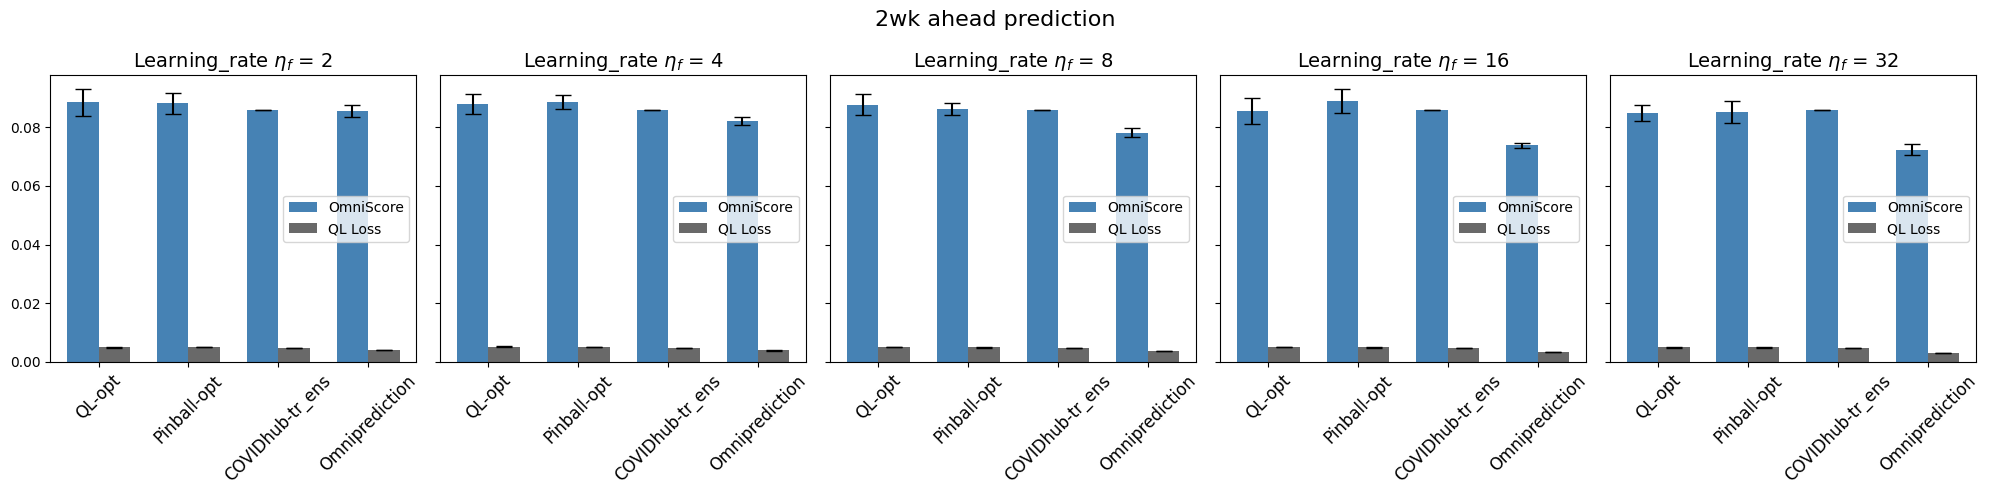

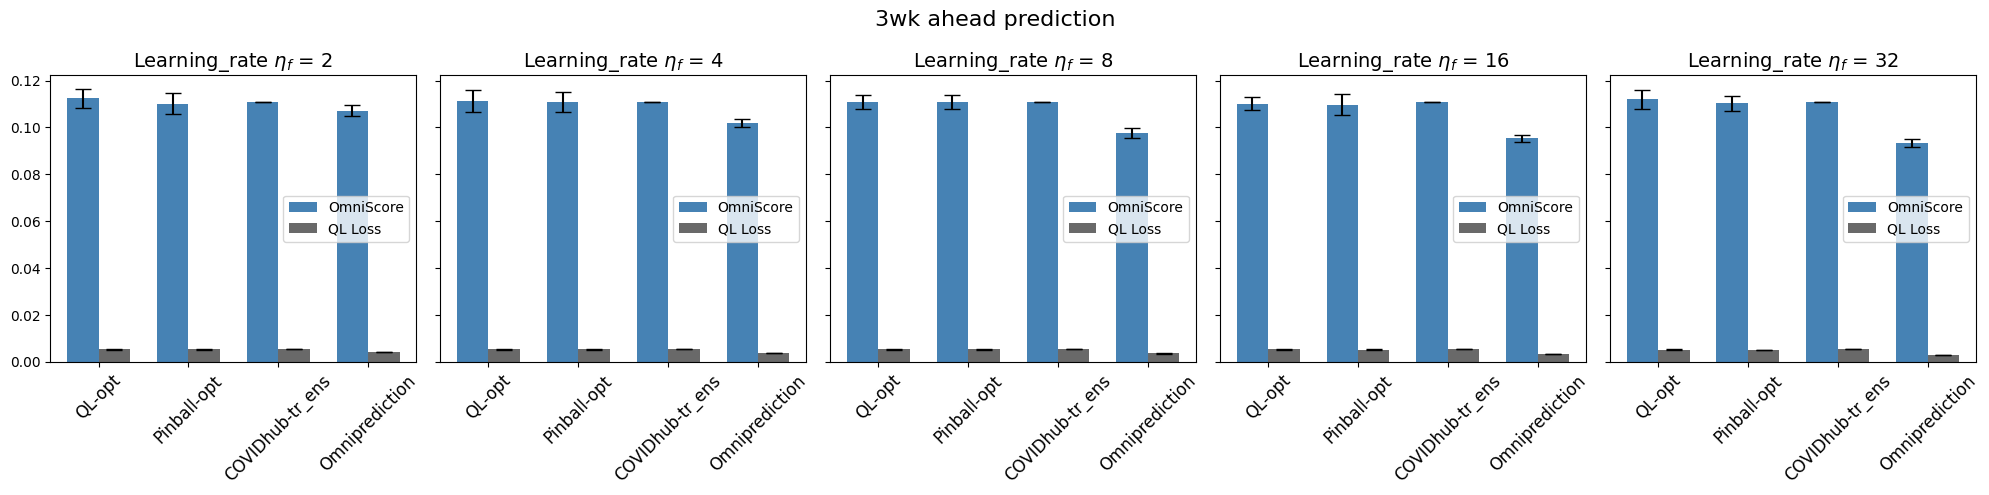

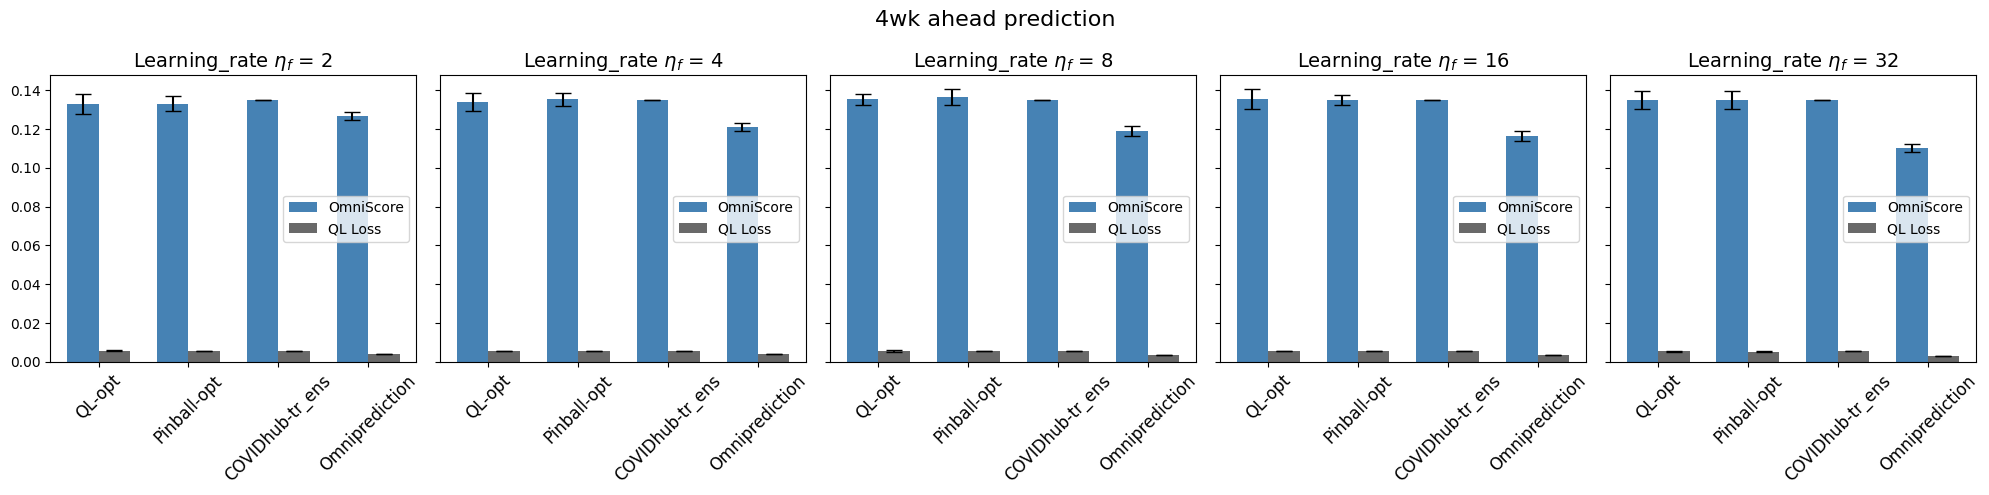

In [80]:
from metrics import elementary_scores_grid_T_N

alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])
n_seeds = 10
eta_multiplier = 1

for iw, w in enumerate(range(1,5)):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
    for iefm, eta_f_multiplier in enumerate([1, 2, 4, 8, 16]):
        ax = axes[iefm]
        
        ql_omni_score = np.zeros(n_seeds)
        pb_omni_score = np.zeros(n_seeds)
        ens_omni_score = np.zeros(n_seeds)
        omni_omni_score = np.zeros(n_seeds)
        
        ql_ql_loss = np.zeros(n_seeds)
        pb_ql_loss = np.zeros(n_seeds)
        ens_ql_loss = np.zeros(n_seeds)
        omni_ql_loss = np.zeros(n_seeds)

        for seed in range(1,n_seeds+1):
            omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)}.pkl", 'rb'))
            results = omni_result.results
            
            T = results['T']
            Y = results['Y']
            m = results['m']
            thetas = results['thetas']

            ens_preds = results['forecasters_preds_history'][:,:,-1]    # COVIDhub-trained_ensemble
            ensemble_scores = elementary_scores_grid_T_N(ens_preds, Y.values, thetas, alpha_list_here)
            ensemble_omni_score_trace = np.max(np.cumsum(ensemble_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

            ql_omni_score[seed-1] = omni_result.ql_omni_score_trace[T-1]
            pb_omni_score[seed-1] = omni_result.pinball_omni_score_trace[T-1]
            ens_omni_score[seed-1] = ensemble_omni_score_trace[T-1]
            omni_omni_score[seed-1] = results['omni_score_trace'][T-1]
            
            ql_ql_loss[seed-1] = ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m
            pb_ql_loss[seed-1] = ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m
            ens_ql_loss[seed-1] = ql_loss(ens_preds, Y, results['alpha_list']).mean()/m
            omni_ql_loss[seed-1] = ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m

        # Bar positions: 3 groups, 2 bars per group (omni_score, ql_loss)
        labels = ['QL-opt', 'Pinball-opt', 'COVIDhub-tr_ens', 'Omniprediction']
        x = np.arange(4)
        width = 0.35  # width of each bar

        mean_omni = [ql_omni_score.mean(), pb_omni_score.mean(), ens_omni_score.mean(), omni_omni_score.mean()]
        std_omni = [ql_omni_score.std(), pb_omni_score.std(), ens_omni_score.std(), omni_omni_score.std()]
        mean_ql = [ql_ql_loss.mean(), pb_ql_loss.mean(), ens_ql_loss.mean(), omni_ql_loss.mean()]
        std_ql = [ql_ql_loss.std(), pb_ql_loss.std(), ens_ql_loss.std(), omni_ql_loss.std()]

        bars1 = ax.bar(x - width/2, mean_omni, width, yerr=std_omni, color='steelblue', capsize=6, label='OmniScore')
        bars2 = ax.bar(x + width/2, mean_ql, width, yerr=std_ql, color='dimgray', capsize=6, label='QL Loss')
        

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, fontsize=12)
        ax.set_title(rf'Learning_rate $\eta_f$ = {eta_f_multiplier*2}', fontsize=14)
        ax.legend()

        fig.suptitle(f'{w}wk ahead prediction', fontsize=16)
        fig.tight_layout()

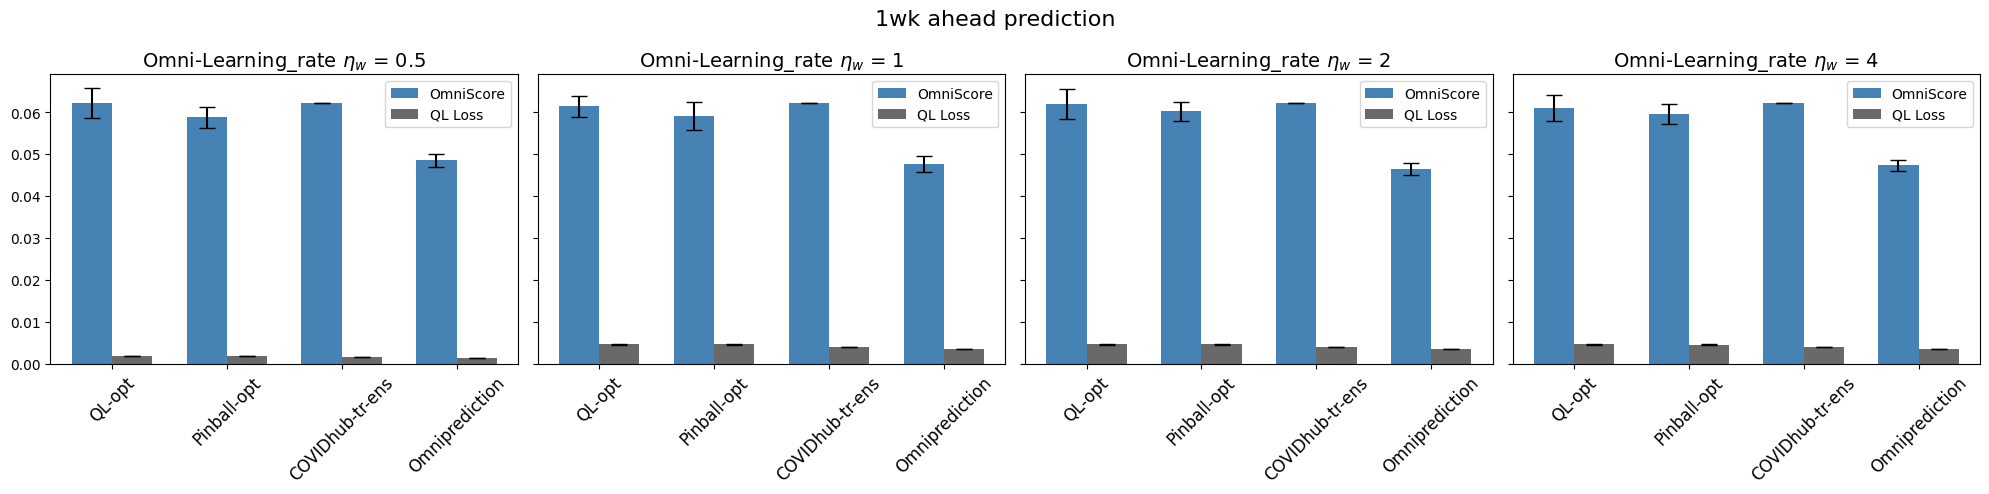

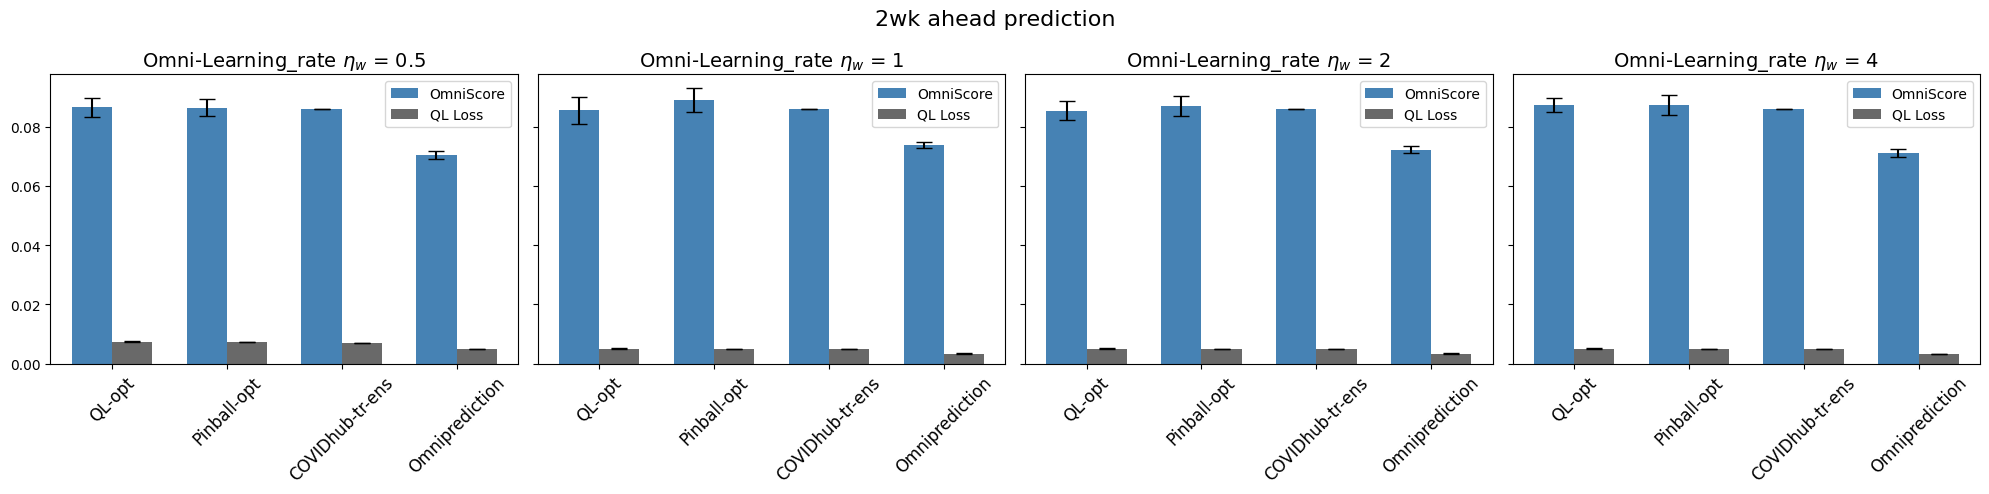

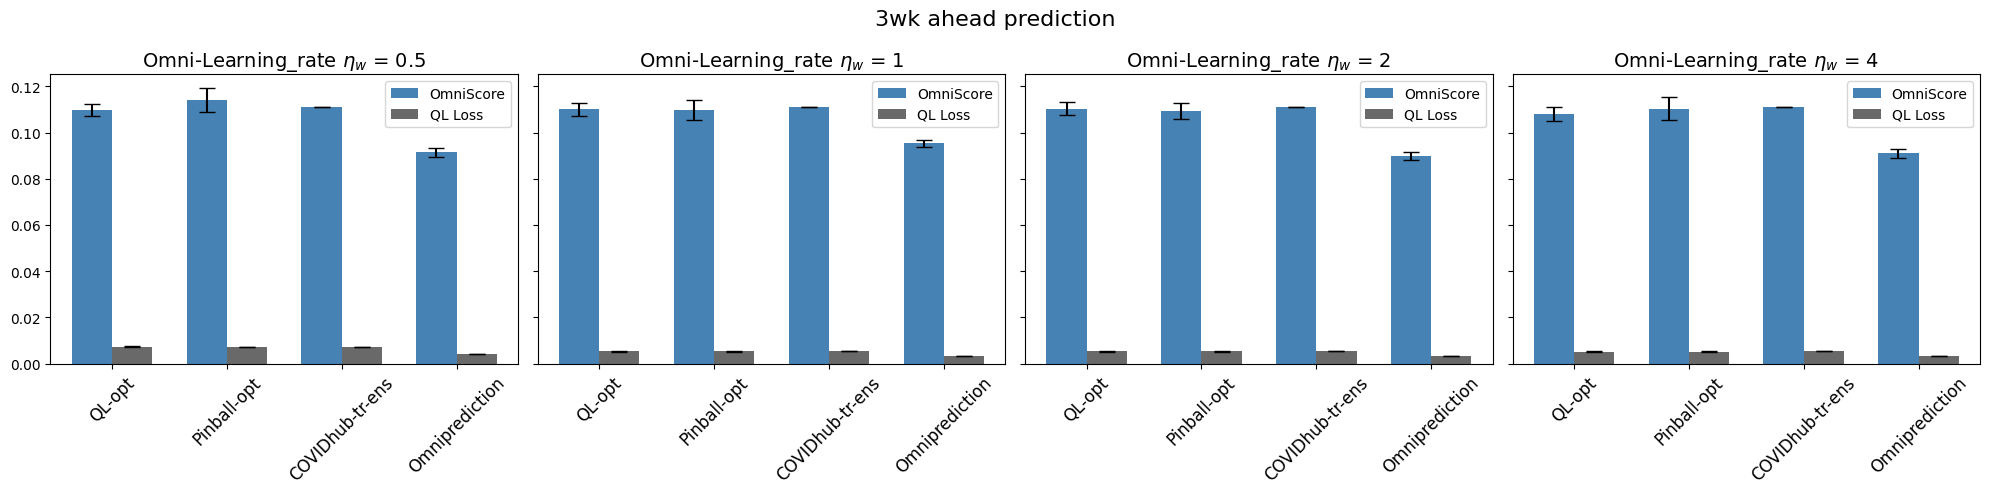

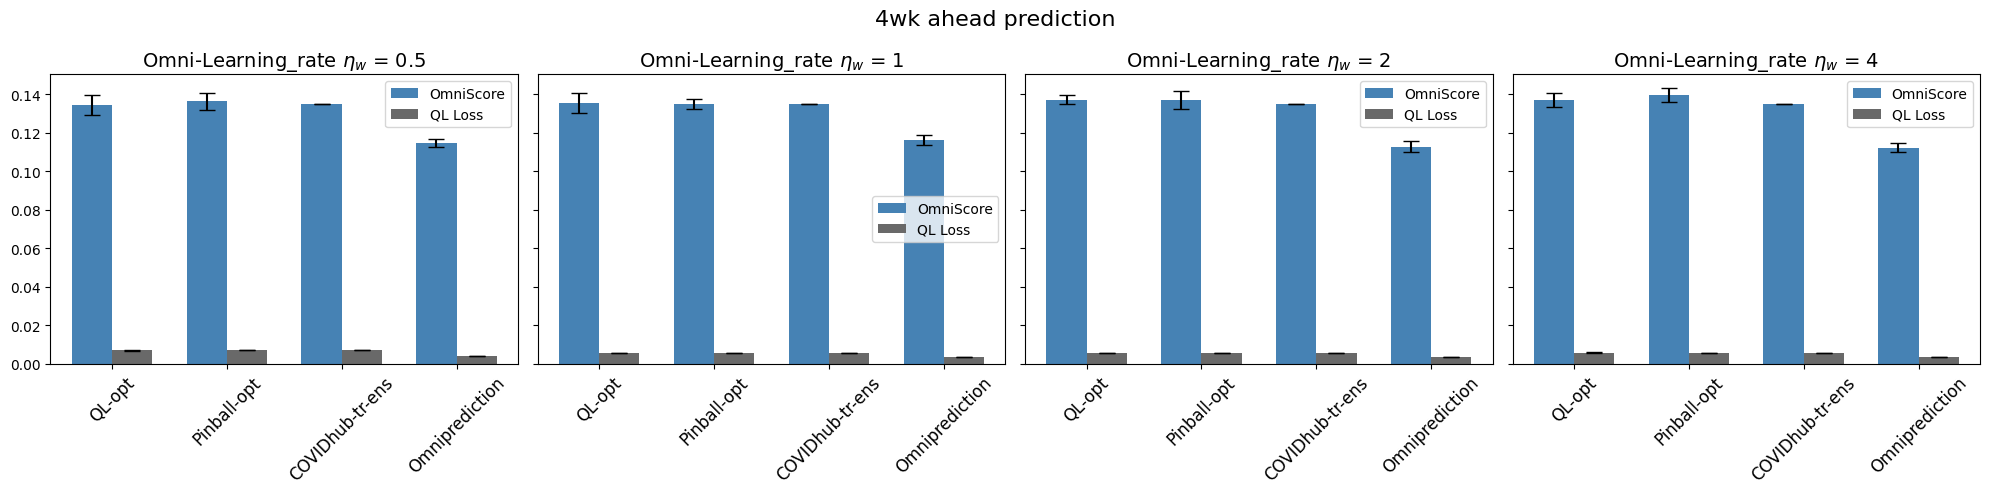

In [84]:
from metrics import elementary_scores_grid_T_N

alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])
eta_f_multiplier = 8

for iw, w in enumerate(range(1,5)):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    for iefm, eta_multiplier in enumerate([0.5, 1, 2, 4]):
        ax = axes[iefm]

        T = results['T']
        Y = results['Y']
        m = results['m']
        thetas = results['thetas']

        ql_omni_score = np.zeros(10)
        pb_omni_score = np.zeros(10)
        ens_omni_score = np.zeros(10)
        omni_omni_score = np.zeros(10)
        
        ql_ql_loss = np.zeros(10)
        pb_ql_loss = np.zeros(10)
        ens_ql_loss = np.zeros(10)
        omni_ql_loss = np.zeros(10)

        for seed in range(1,11):
            omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name_string(w, eta_multiplier, eta_f_multiplier, seed)}.pkl", 'rb'))
            results = omni_result.results
            
            ens_preds = results['forecasters_preds_history'][:,:,-1]
            ensemble_scores = elementary_scores_grid_T_N(ens_preds, Y.values, thetas, alpha_list_here)
            ensemble_omni_score_trace = np.max(np.cumsum(ensemble_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

            ql_omni_score[seed-1] = omni_result.ql_omni_score_trace[T-1]
            pb_omni_score[seed-1] = omni_result.pinball_omni_score_trace[T-1]
            ens_omni_score[seed-1] = ensemble_omni_score_trace[T-1]
            omni_omni_score[seed-1] = results['omni_score_trace'][T-1]
            
            ql_ql_loss[seed-1] = ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m
            pb_ql_loss[seed-1] = ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m
            ens_ql_loss[seed-1] = ql_loss(ens_preds, Y, results['alpha_list']).mean()/m
            omni_ql_loss[seed-1] = ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m

        # Bar positions: 3 groups, 2 bars per group (omni_score, ql_loss)
        labels = ['QL-opt', 'Pinball-opt', 'COVIDhub-tr-ens', 'Omniprediction']
        x = np.arange(4)
        width = 0.35  # width of each bar

        mean_omni = [ql_omni_score.mean(), pb_omni_score.mean(), ens_omni_score.mean(), omni_omni_score.mean()]
        std_omni = [ql_omni_score.std(), pb_omni_score.std(), ens_omni_score.std(), omni_omni_score.std()]
        mean_ql = [ql_ql_loss.mean(), pb_ql_loss.mean(), ens_ql_loss.mean(), omni_ql_loss.mean()]
        std_ql = [ql_ql_loss.std(), pb_ql_loss.std(), ens_ql_loss.std(), omni_ql_loss.std()]

        bars1 = ax.bar(x - width/2, mean_omni, width, yerr=std_omni, color='steelblue', capsize=6, label='OmniScore')
        bars2 = ax.bar(x + width/2, mean_ql, width, yerr=std_ql, color='dimgray', capsize=6, label='QL Loss')
        

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45,fontsize=12)
        ax.set_title(rf'Omni-Learning_rate $\eta_w$ = {eta_multiplier}', fontsize=14)
        ax.legend()

        fig.suptitle(f'{w}wk ahead prediction', fontsize=16)
        fig.tight_layout()

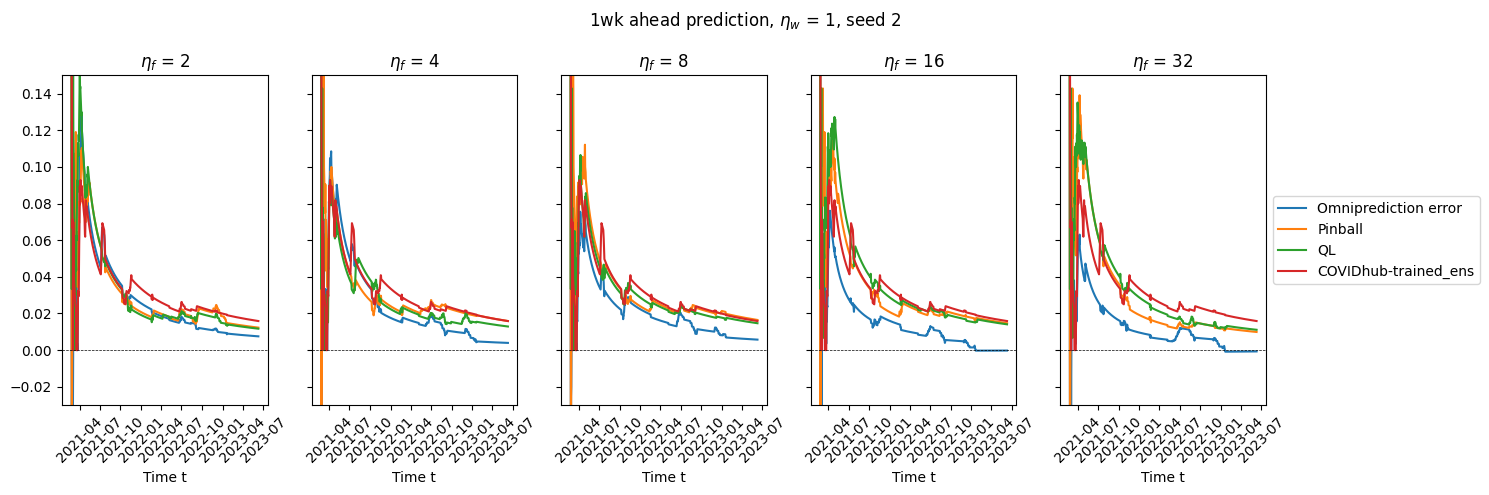

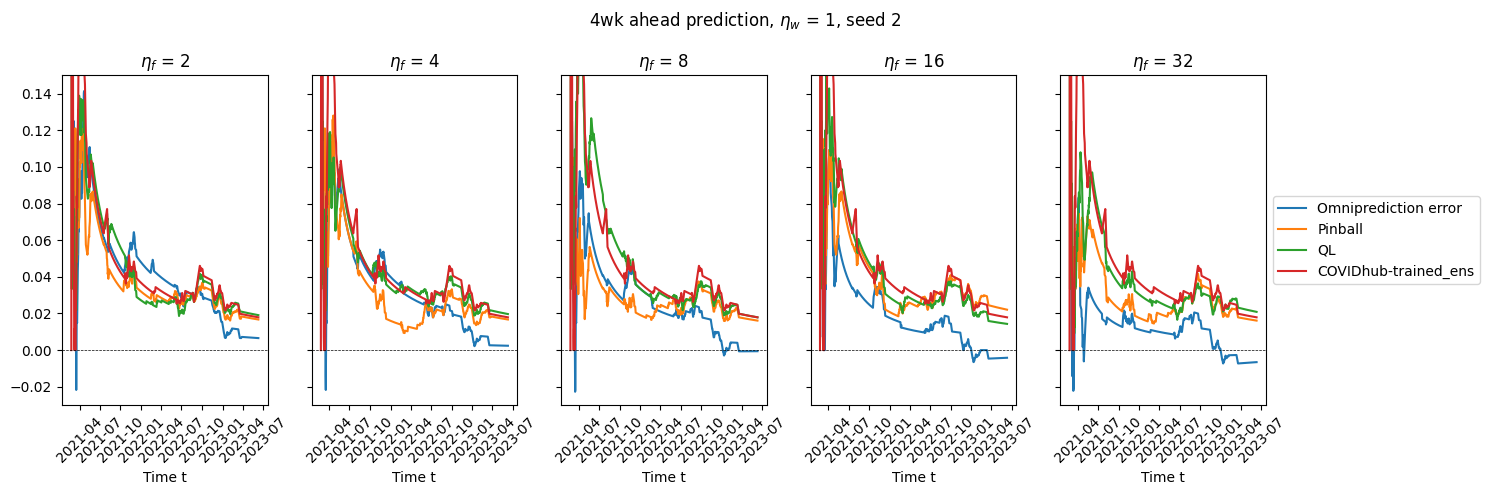

In [87]:
for w in [1,4]:
    fig, ax = plt.subplots(1, 5, figsize=(15, 5), sharey=True)

    for i, eta_f_multiplier in enumerate([1,2,4,8,16]):
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string(w, 1, eta_f_multiplier, 2)}.pkl", 'rb'))
        omni_result = OmniResult(results)
        omni_result.simple_plot(ax=ax[i])
        ax[i].set_title(rf'$\eta_f$ = {2*eta_f_multiplier}')
        if i == 4:
            ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))

    ax[4].set_ylim(-0.03, 0.15)
    fig.suptitle(rf'{w}wk ahead prediction, $\eta_w$ = 1, seed 2')
    fig.tight_layout()
    plt.show()

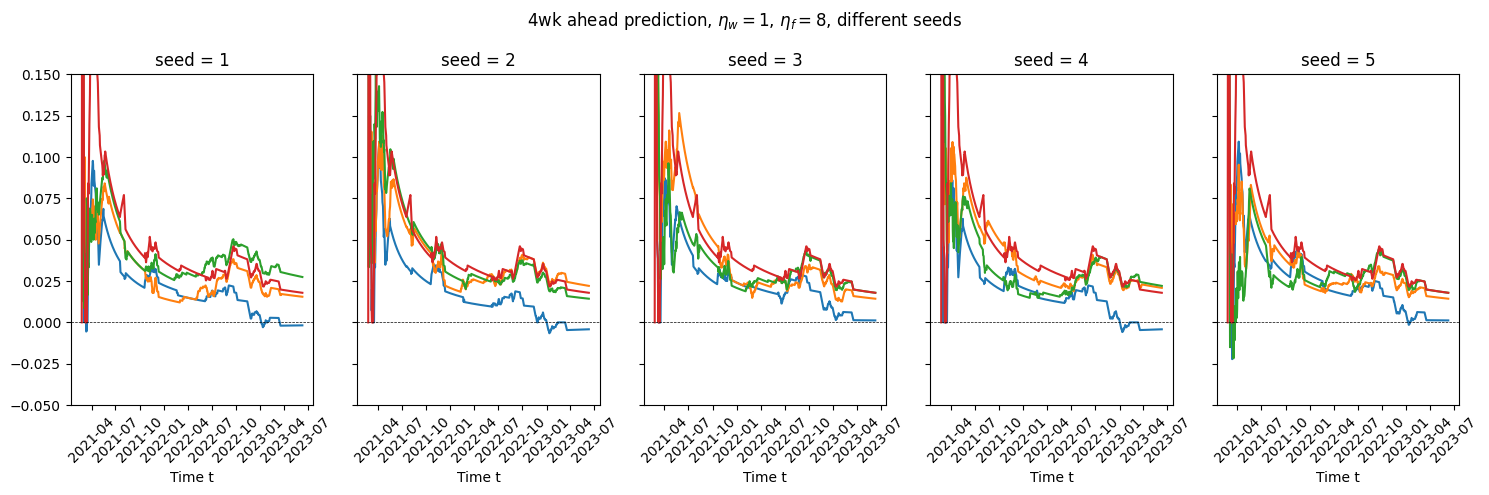

In [89]:

fig, ax = plt.subplots(1, 5, figsize=(15, 5), sharey=True)
w=4
for i, seed in enumerate(range(1,6)):
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string(w, 1, 8, seed)}.pkl", 'rb'))
    omni_result = OmniResult(results)
    omni_result.simple_plot(ax=ax[i])
    ax[i].set_title(f'seed = {seed}')

ax[4].set_ylim(-0.05, 0.15)
fig.suptitle(fr'{w}wk ahead prediction, $\eta_w = 1$, $\eta_f = 8$, different seeds')
fig.tight_layout()
plt.show()

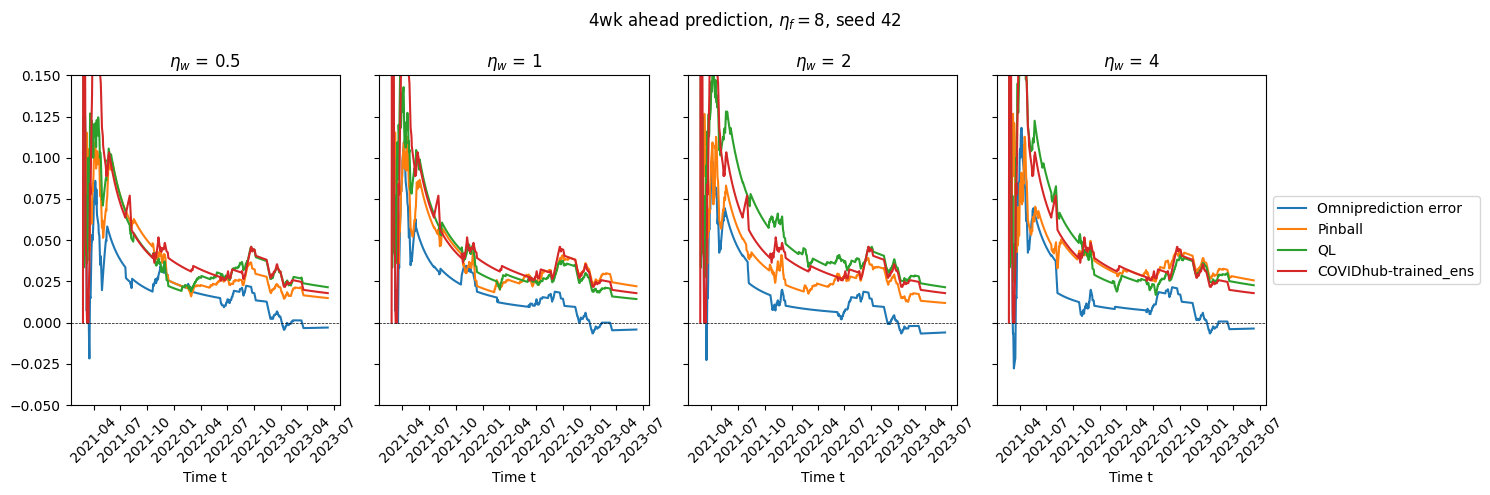

In [94]:

fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharey=True)

w=4
for i, eta_multiplier in enumerate([0.5, 1, 2, 4]):
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string(w, eta_multiplier, 8, 2)}.pkl", 'rb'))
    omni_result = OmniResult(results)
    omni_result.simple_plot(ax=ax[i])
    ax[i].set_title(fr'$\eta_w$ = {eta_multiplier}')

ax[3].set_ylim(-0.05, 0.15)
ax[3].legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.suptitle(fr'{w}wk ahead prediction, $\eta_f = 8$, seed 42')
fig.tight_layout()
plt.show()

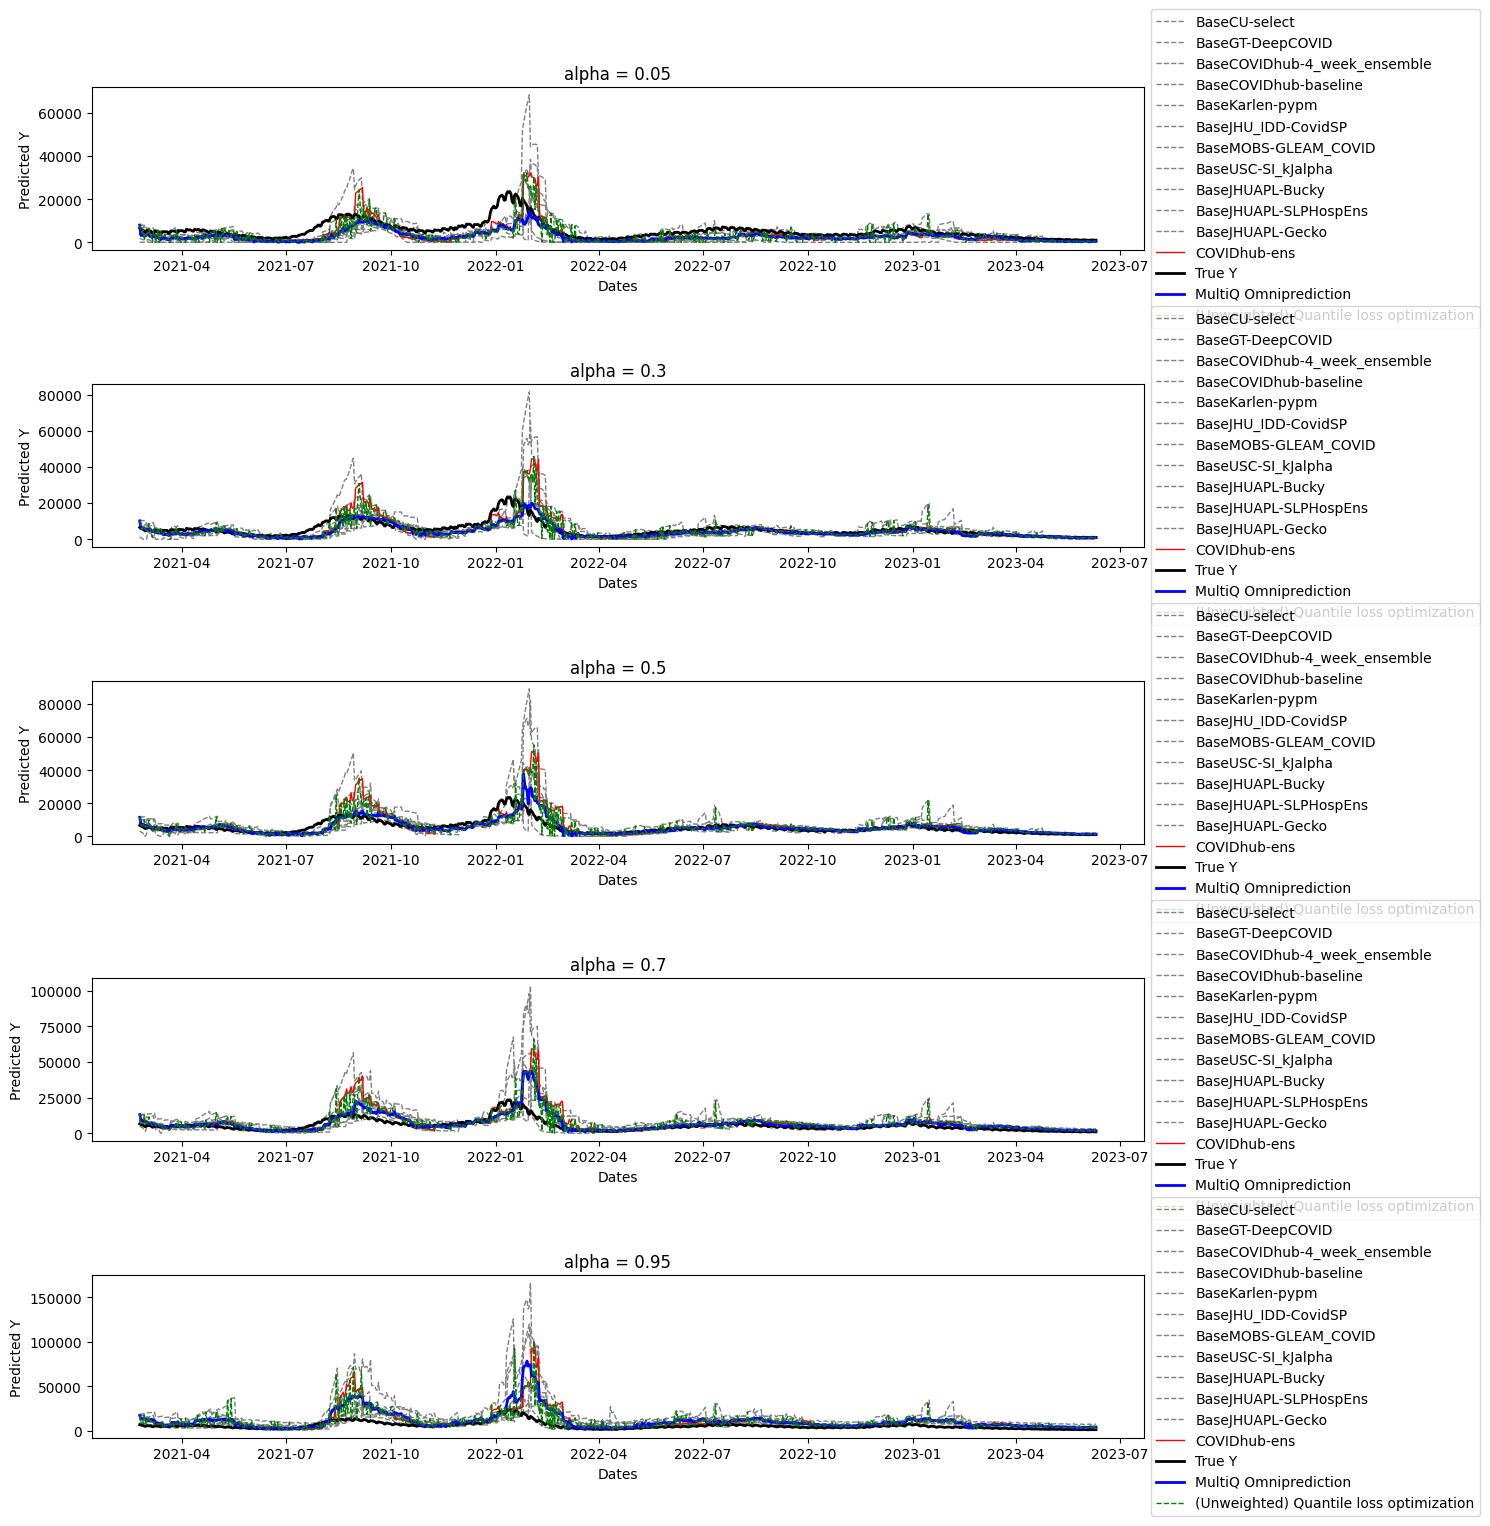

In [95]:
w=4
results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string(w, 1, 8, 1)}.pkl", 'rb'))
omni_result = OmniResult(results)
omni_result.plot_prediction_panel_all()

# QL seems more conservative and towards the center 0.5 AND have smaller omniprediction error CHECK
# Pinball loss does follow omniprediction pretty closely. CHECK why


# Omniprediction error calculation check for QL and Pinball, try Pinball with post-sort, and see pinball chooses different model for each quantile level CHECK
# What's happening for alpha=0.1? why is all the models predicting downward trend oppopsed to Y's upward trend?
# Index check

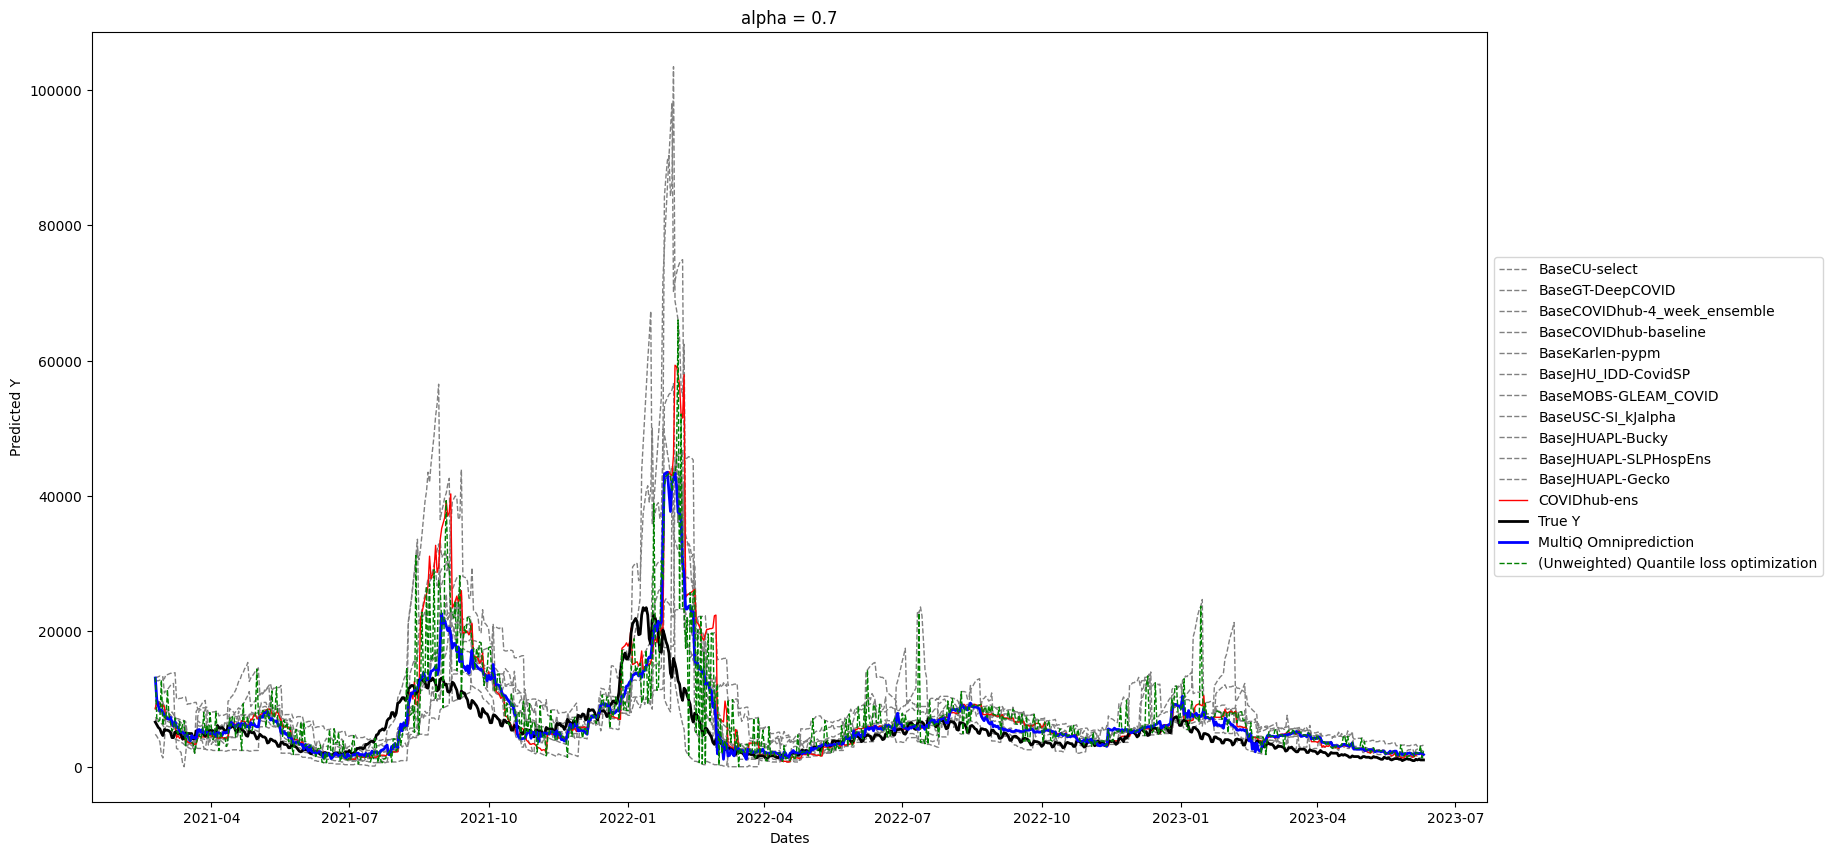

In [98]:
ia = 3
omni_result.plot_prediction_panel(alpha=alpha_list_here[ia], relative=False)

## Plot actual quantile error

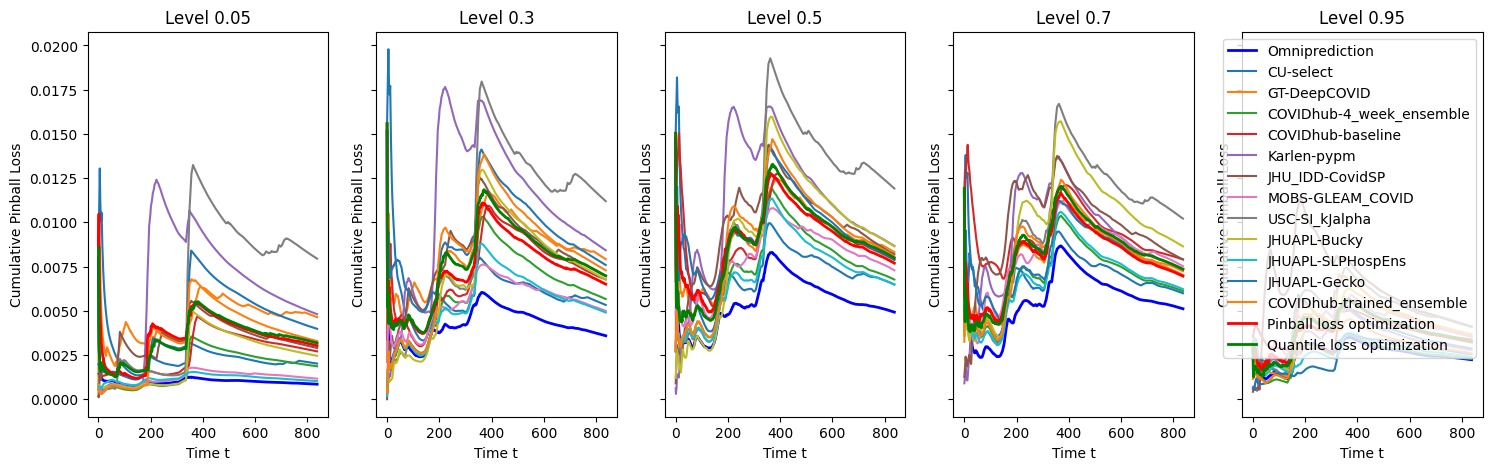

In [100]:
T = results['T']
F = results['F']
m = results['m']
forecaster_names = results['forecaster_names']

fig, ax = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
for ia, alpha in enumerate(alpha_list_here):    
    df = omni_result.single_q_pred_df(ia)
    ax[ia].plot(pinball_loss(df["phat"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, color='blue', linewidth=2,label='Omniprediction')
    for f in range(F):
        ax[ia].plot(pinball_loss(df[f"pred_{f+1}"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, label=forecaster_names[f])
    ax[ia].plot(pinball_loss(df["pinball_pred"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, color='red', linewidth=2, label='Pinball loss optimization')
    ax[ia].plot(pinball_loss(df["ql_pred"], df["Y"], alpha).cumsum() / np.arange(1, T+1) / m, color='green', linewidth=2, label='Quantile loss optimization')
    if ia == 4:
        ax[ia].legend()
    ax[ia].set_xlabel('Time t')
    ax[ia].set_ylabel('Cumulative Pinball Loss')
    ax[ia].set_title(f'Level {alpha}')
plt.show()


# fig, ax = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
# for ia, alpha in enumerate(alpha_list_here):    
#     df = omni_result.single_q_pred_df(ia)
#     ax[ia].plot(pinball_loss(df["phat"], df["Y"], alpha), color='blue', linewidth=2,label='Omniprediction')
#     for f in range(F):
#         ax[ia].plot(pinball_loss(df[f"pred_{f+1}"], df["Y"], alpha), label=forecaster_names[f])
#     if ia == 4:
#         ax[ia].legend()
#     ax[ia].set_xlabel('Time t')
#     ax[ia].set_ylabel('Cumulative Pinball Loss')
#     ax[ia].set_title(f'Level {alpha}')
#     ax[ia].set_ylim(0, 50)
# plt.show()




# Find threshold that omniprediction works the best.
# OR consider only optimizing over weighted pinball loss. 

In [120]:
alpha_list_here = [0.05, 0.3 , 0.5 , 0.7 , 0.95]

array([0.05, 0.3 , 0.5 , 0.7 , 0.95])

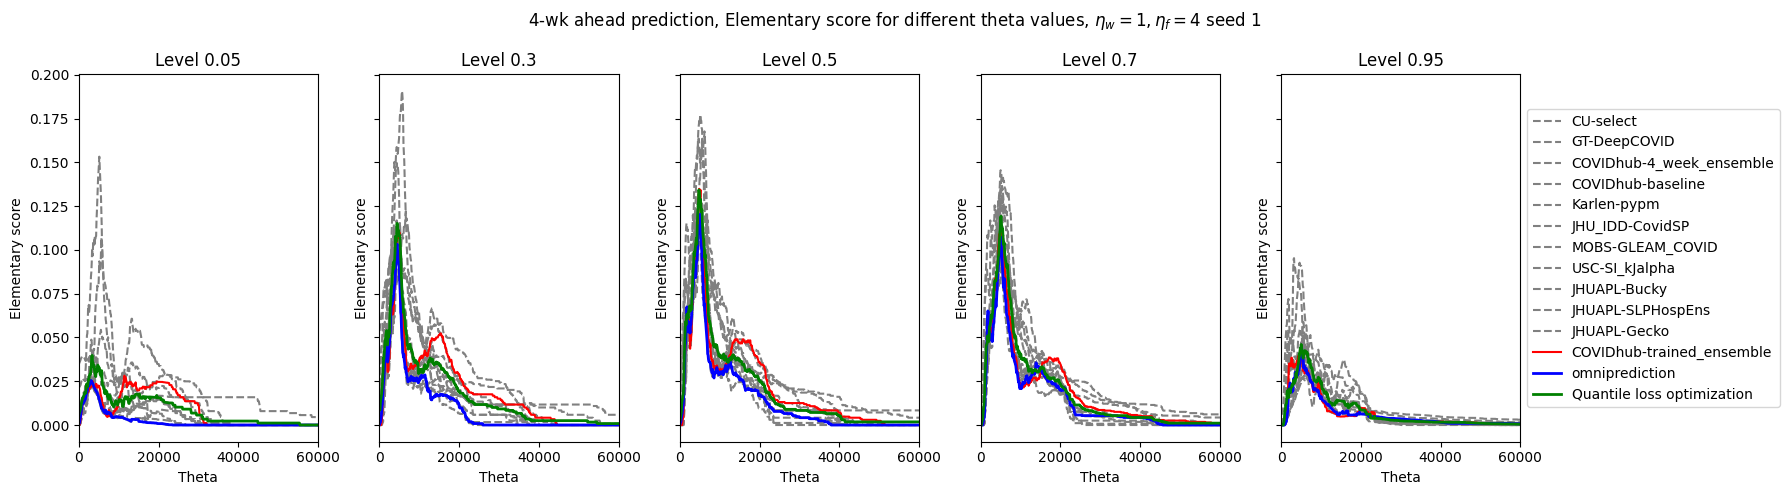

In [105]:
w=4
results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string(w, 1, 4, 1)}.pkl", 'rb'))
omni_result = OmniResult(results)

alpha_list = results['alpha_list']
thetas = results['thetas']
unit = results['unit']
F = results['F']
forecaster_names = results['forecaster_names']

scoring_functions, _ = create_scoring_function_class(
                                        alpha_list=alpha_list,
                                        thetas=thetas
                                    )   # (F, m)

fig, ax = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
omni_max = 0
pinball_max = 0
ql_max = 0

for ia, alpha in enumerate(alpha_list):
    df = omni_result.single_q_pred_df(ia)
    
    omni_max = max(omni_max, max([s(df["phat"], df["Y"]) for s in scoring_functions[ia]]))
    for f in range(F):
        if f < F-1:
            ax[ia].plot(thetas*unit, [s(df[f"pred_{f+1}"], df["Y"]) for s in scoring_functions[ia]], linestyle='--', color='gray', label=forecaster_names[f])
        else:
            ax[ia].plot(thetas*unit, [s(df[f"pred_{f+1}"], df["Y"]) for s in scoring_functions[ia]], linestyle='-', color='red', label=forecaster_names[f])
    # ax[ia].plot(thetas*unit, [s(df["pinball_pred"], df["Y"]) for s in scoring_functions[ia]], color='red', linewidth=2, label='Pinball loss optimization')
    ax[ia].plot(thetas*unit, [s(df["phat"], df["Y"]) for s in scoring_functions[ia]], color='blue', linewidth=2, label='omniprediction')
    pinball_max = max(pinball_max, max([s(df["pinball_pred"], df["Y"]) for s in scoring_functions[ia]]))
    ax[ia].plot(thetas*unit, [s(df["ql_pred"], df["Y"]) for s in scoring_functions[ia]], color='green', linewidth=2, label='Quantile loss optimization')
    ql_max = max(ql_max, max([s(df["ql_pred"], df["Y"]) for s in scoring_functions[ia]]))
    if ia == 4:
        ax[ia].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[ia].set_xlabel('Theta')
    ax[ia].set_ylabel('Elementary score')
    ax[ia].set_title(f'Level {alpha}')
    ax[ia].set_xlim(0, 60000)
fig.suptitle(rf'{w}-wk ahead prediction, Elementary score for different theta values, $\eta_w=1, \eta_f=4$ seed 1')
fig.tight_layout()
plt.show()



# Others

In [140]:
omni_max, pinball_max, ql_max

(np.float64(0.0560655737704918),
 np.float64(0.0453551912568306),
 np.float64(0.048633879781420766))

In [171]:
omni_result.results['omni_score_trace'][-1], omni_result.pinball_omni_score_trace[-1], omni_result.ql_omni_score_trace[-1]


# minimax is 0. WHY


(np.float64(0.0546448087431694),
 np.float64(0.0546448087431694),
 np.float64(0.05191256830601087))

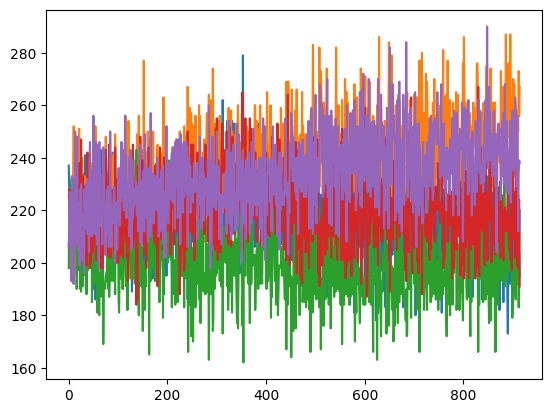

In [147]:
# For each slice along the first dimension, count the occurrences of 0, 1, 2, 3, 4.
# Output will be an array with shape (orig_mtx[0], 5), i.e., (results['forecasters_selection_history'].shape[0], 5)
import numpy as np
hist = np.stack([
    np.sum(results['forecasters_selection_history'] == i, axis=(1,2))
    for i in range(5)
], axis=1)

for n in range(5):
    plt.plot(hist[:, n])

7.849299078504574e-06
(array([786]), array([1]), array([41]))
[2.23161553e-09 2.93058095e-06 5.02245992e-09 1.64895804e-10
 9.99997059e-01 3.06403638e-09]


(array([2326896.,  277562.,  185512.,  129181.,  121983.,  100190.,
          74673.,   64994.,   78706.,   74227.,   96764.,   53957.,
          48892.,   59841.,   50808.,   56218., 1095109.,   78135.,
         105284.,  274159.,  157137.,   49875.,   48482.,   76292.,
         100091.,   52723.,   42209.,   45683.,   57114.,   33695.,
          32051.,   50264.,   62398.,   23052.,   22559.,   22586.,
          26031.,   22078.,   18474.,   23728.,   16110.,   14528.,
          19819.,   17399.,   12482.,   20725.,   14606.,   16039.,
          19284.,   31546.,    9682.,   10417.,   10921.,   14354.,
           9788.,   15989.,   10772.,    8905.,   10884.,    8323.,
          15364.,    6497.,   11169.,   11374.,   11198.,   10957.,
          19357.,   11610.,    7689.,   10461.,   10296.,    9889.,
          13811.,    9295.,    6523.,   12605.,    7124.,   10260.,
          10256.,    9211.,   15747.,    5727.,    9666.,    9163.,
          10532.,    7206.,    8058.,   10273., 

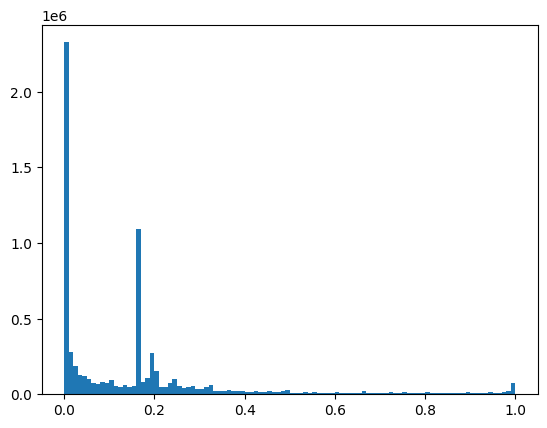

In [182]:
results['v_history']  # (T, N, m, F)
# cross entropy along axis 3
v_history_ce = -np.sum(results['v_history'] * np.log(results['v_history']), axis=3)
print(v_history_ce.min())
print(np.where(v_history_ce == v_history_ce.min()))
print(results['v_history'][802,2,42])
plt.hist(results['v_history'].flatten(), bins=100)


# pinball loss and QL loss are much larger than elementary loss -> that's why omniprediction is bad right now. 
# But why..? we are on the right scale though..


# 4x eta_f makes omniprediction very good. 
# but why is minimax value still very small? while f_i^s keep changing?